In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset/LD2011_2014.txt", delimiter=";", decimal=",")
df["Time"] = pd.to_datetime(df.pop("Unnamed: 0"), format="%Y-%m-%d %H:%M:%S")
df = df.set_index("Time")

C:\Users\atopo\AppData\Local\Temp\ipykernel_33572\4161421177.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Time"] = pd.to_datetime(df.pop("Unnamed: 0"), format="%Y-%m-%d %H:%M:%S")


In [17]:
df.columns

Index(['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007',
       'MT_008', 'MT_009', 'MT_010',
       ...
       'MT_362', 'MT_363', 'MT_364', 'MT_365', 'MT_366', 'MT_367', 'MT_368',
       'MT_369', 'MT_370', 'Time'],
      dtype='str', length=371)

In [19]:
df.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370,Time
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011-01-01 00:15:00
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011-01-01 00:30:00
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011-01-01 00:45:00
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011-01-01 01:00:00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011-01-01 01:15:00


In [35]:
print("Latest", df.index.max())
print("Earliest", df.index.min())
print("Rows", df.shape[0])

Latest 2015-01-01 00:00:00
Earliest 2011-01-01 00:15:00
Rows 140256


<Axes: >

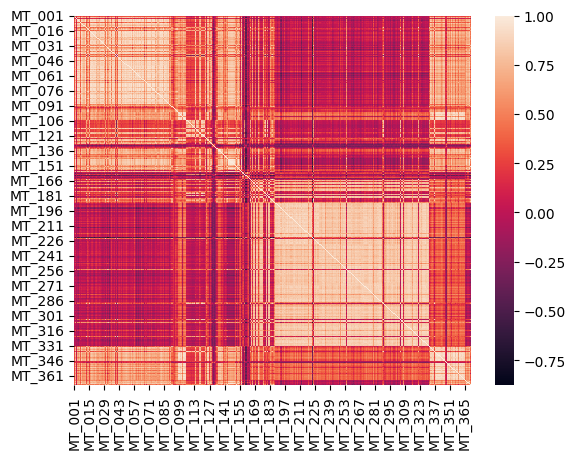

In [36]:
import seaborn as sns

sns.heatmap(df.corr())

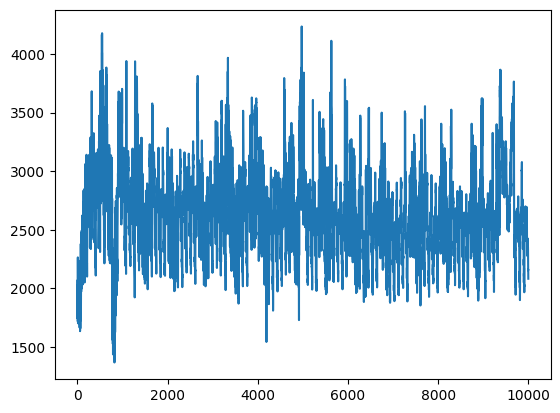

In [28]:
plt.plot(df[:10000]["MT_163"])

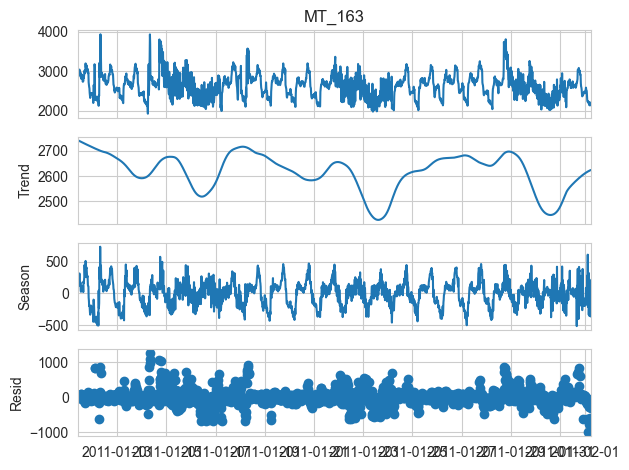

In [9]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["MT_163"][1000:3000], period=100, robust=True)
res = stl.fit()
res.plot()
plt.show()

In [16]:
from statsmodels.tsa.stattools import adfuller

adfuller(df["MT_163"])

(np.float64(-22.630998294384913),
 0.0,
 73,
 140182,
 {'1%': np.float64(-3.4303966494967137),
  '5%': np.float64(-2.8615606184118194),
  '10%': np.float64(-2.5667809744477768)},
 np.float64(1795134.4043266815))

Time series is stationary, we should check across other variables